# 2. Editing trees and building synthetic ones

Two halves:

1. **Editing** an existing reconstruction — repair, resample, prune, transform.
2. **Generating** a synthetic arbor from scratch with `MST_tree`.

Everything returns a **new** tree. Unlike the MATLAB toolbox there is no hidden
global `trees` array, so if you don't assign the result it's lost.

In [1]:
import numpy as np
import pynetrees as pt

tree = pt.repair_tree(pt.sample_tree())
print(tree, f"| total length {pt.len_tree(tree).sum():.0f} um")

Tree(name='sample', n_nodes=197, regions=[dendrite, subtree]) | total length 765 um


## Resampling

`resample_tree` redistributes nodes to a target spacing. It **preserves branch
and termination points exactly** and only resamples the interior of each
section — so the topology is untouched and only the sampling density changes.

(The MATLAB version snaps branch points onto the resampling grid instead. This
is a deliberate difference — see `PORT_STATUS.md` design decision #23.)

In [2]:
for sr in (2.0, 10.0, 25.0):
    rs = pt.resample_tree(tree, sr)
    print(f"sr={sr:5.1f} um -> {rs.n_nodes:5d} nodes "
          f"| branch pts {pt.B_tree(rs).sum():3d} "
          f"| tips {pt.T_tree(rs).sum():3d} "
          f"| length {pt.len_tree(rs).sum():.0f} um")

print(f"\noriginal   -> {tree.n_nodes:5d} nodes "
      f"| branch pts {pt.B_tree(tree).sum():3d} "
      f"| tips {pt.T_tree(tree).sum():3d}")

sr=  2.0 um ->   383 nodes | branch pts  25 | tips  26 | length 755 um
sr= 10.0 um ->    78 nodes | branch pts  19 | tips  23 | length 725 um
sr= 25.0 um ->    30 nodes | branch pts  10 | tips  17 | length 671 um

original   ->   197 nodes | branch pts  25 | tips  26


Branch-point and tip counts stay constant across every resampling — that's the
guarantee. Total length barely moves; it changes slightly because resampling
straightens the polyline within each section.

## Pruning

`clean_tree` removes short spurious branches (reconstruction artefacts).
`delete_tree` removes nodes you choose, splicing survivors to their nearest
surviving ancestor.

In [3]:
cleaned = pt.clean_tree(tree, radius=5.0)
print(f"clean_tree(radius=5): {tree.n_nodes} -> {cleaned.n_nodes} nodes")

# drop everything beyond 200 um of path length
plen = pt.Pvec_tree(tree, pt.len_tree(tree))
far = np.flatnonzero(plen > 200)
pruned = pt.delete_tree(tree, far)
print(f"delete_tree(path > 200um): {tree.n_nodes} -> {pruned.n_nodes} nodes")
print("(delete_tree returns a list[Tree] instead if the deletion disconnects the tree)")

clean_tree(radius=5): 197 -> 194 nodes
delete_tree(path > 200um): 197 -> 197 nodes
(delete_tree returns a list[Tree] instead if the deletion disconnects the tree)


## Transforms

All the usual rigid/scaling operations, plus `flatten_tree`, which projects the
arbor onto the XY plane *while conserving every segment's length* (subtrees are
pushed outward to absorb the lost Z extent).

In [4]:
moved   = pt.tran_tree(tree, [100.0, 0.0, 0.0])
rotated = pt.rot_tree(tree, (0.0, 0.0, 45.0))
scaled  = pt.scale_tree(tree, 2.0)
flat    = pt.flatten_tree(tree)

print(f"tran_tree   : x centre {tree.X.mean():7.1f} -> {moved.X.mean():7.1f}")
print(f"scale_tree  : total len {pt.len_tree(tree).sum():7.0f} -> {pt.len_tree(scaled).sum():7.0f}")
print(f"flatten_tree: max |Z|   {np.abs(tree.Z).max():7.1f} -> {np.abs(flat.Z).max():7.1f}")
print(f"              total len {pt.len_tree(tree).sum():7.1f} -> {pt.len_tree(flat).sum():7.1f}  (conserved)")

tran_tree   : x centre    67.2 ->   167.2
scale_tree  : total len     765 ->    1530
flatten_tree: max |Z|      35.5 ->     0.0
              total len   765.2 ->   765.2  (conserved)


## Building a synthetic tree

`MST_tree` grows an arbor over a point cloud. The key parameter is the
**balancing factor** `bf`, which trades off two competing costs:

- `bf = 0` — minimise total **wiring length** (cheap to build, long paths)
- `bf = 1` — minimise **path length** to the root (fast signalling, more wire)

This is the central idea of the TREES toolbox's generative model.

In [5]:
rng = np.random.default_rng(42)
pts = rng.uniform(-100, 100, size=(250, 3))
pts[:, 2] *= 0.15   # a flattish arbor

synth = {}
for bf in (0.0, 0.5, 1.0):
    # NOTE: MST_tree returns a *tuple* -- the tree plus a mask of which input
    # points actually made it in (points beyond `thr` from everything are
    # dropped). It's the one tree-producing function that does this.
    t, connected = pt.MST_tree(pts[:, 0], pts[:, 1], pts[:, 2], bf=bf, thr=80.0, full_output=True)[:2]
    synth[bf] = t
    total = pt.len_tree(t).sum()
    path = pt.Pvec_tree(t, pt.len_tree(t))
    print(f"bf={bf:.1f}: {t.n_nodes:4d} nodes ({connected.sum()}/{len(pts)} points used) "
          f"| total wiring {total:7.0f} um | mean path to root {path.mean():6.1f} um")

bf=0.0:  250 nodes (250/250 points used) | total wiring    3082 um | mean path to root  260.7 um


bf=0.5:  250 nodes (250/250 points used) | total wiring    3823 um | mean path to root  107.2 um
bf=1.0:  250 nodes (250/250 points used) | total wiring   13483 um | mean path to root   92.4 um


Exactly the expected trade-off: total wiring grows with `bf` while mean path
length to the root shrinks. That inverse relationship is the signature of a
correct implementation — a broken cost function could still produce a valid
tree while getting this backwards or flat.

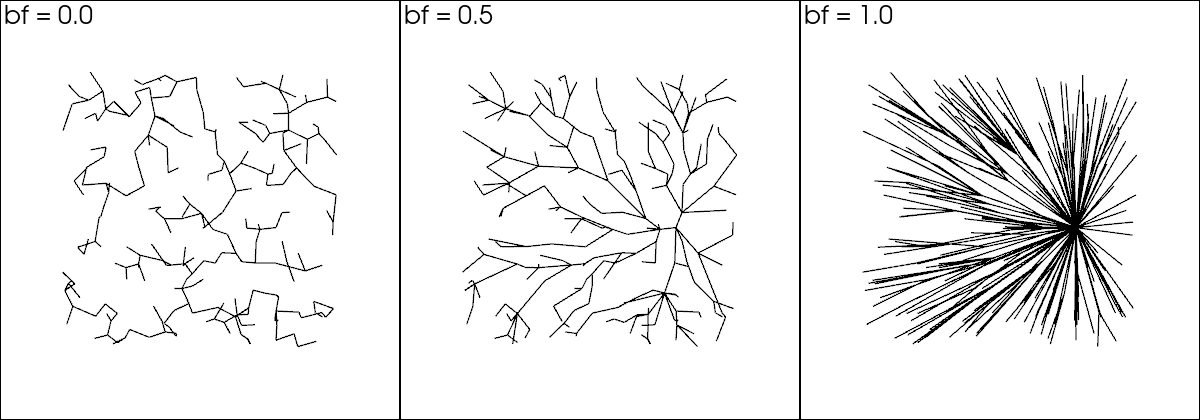

In [6]:
import pyvista as pv

pl = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(1200, 420))
for i, bf in enumerate((0.0, 0.5, 1.0)):
    pl.subplot(0, i)
    pt.plot_tree(synth[bf], color="black", mode="line", plotter=pl)
    pl.add_text(f"bf = {bf}", font_size=11)
    pl.camera_position = "xy"
pl.screenshot("tut02_mst_bf.png")
pl.close()

from IPython.display import Image
Image("tut02_mst_bf.png")

## Making it look like a real neuron

A raw MST has uniform diameters and perfectly straight segments. Three
functions fix that:

diameters: 0.61 - 12.00 um


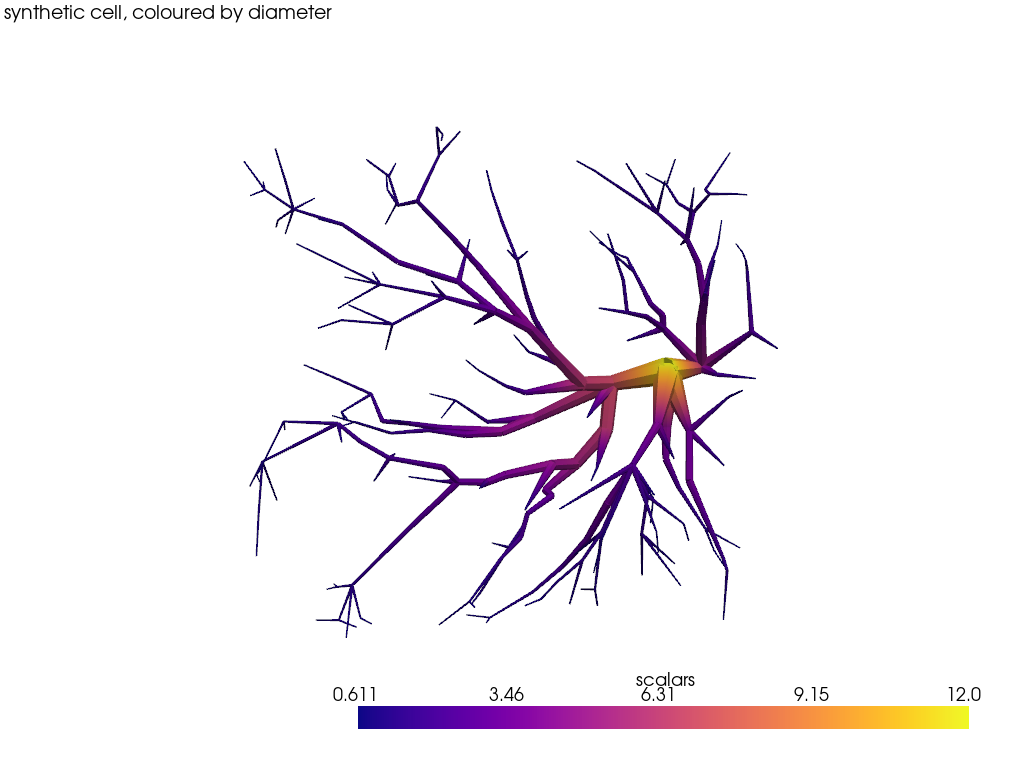

In [7]:
t = synth[0.5]
t = pt.quaddiameter_tree(t)   # realistic tapering: thick at root, thin at tips
t = pt.smooth_tree(t)         # smooth along long paths
t = pt.jitter_tree(t, 1.5)    # spatially-correlated positional noise
t = pt.soma_tree(t, 12.0)     # attach a soma

print(f"diameters: {t.D.min():.2f} - {t.D.max():.2f} um")

pl = pt.plot_tree(t, scalars=t.D, cmap="plasma", mode="tube", res=8)
pl.add_text("synthetic cell, coloured by diameter", font_size=10)
pl.camera_position = "xy"
pl.screenshot("tut02_synthetic.png")
pl.close()

from IPython.display import Image
Image("tut02_synthetic.png")

**Next:** [`03_electrotonics.ipynb`](03_electrotonics.ipynb) — what this
morphology does electrically.